# ResNet Skip Connection Study: Can Periodic Input Re-Injection Help Deep N-BEATS?

**Dataset:** M4-Yearly | **Method:** 3-round successive halving (24 configs)  
**Key question:** The N-BEATS forward pass subtracts backcast from residual at each stack. In deep models (16-30 stacks), does the residual decay starve later stacks of signal, and can ResNet-style skip connections (`alpha * original_input` every `skip_distance` stacks) fix this?

**Three architectures tested:**
- **GenericAELG** — homogeneous AE with learned gates (10, 20, 30 stacks)
- **TrendAELG + WaveletV3AELG** — alternating interpretable+wavelet (8, 16, 24 stacks)  
- **Generic (legacy)** — paper-standard 30-stack (rehabilitation test)

**Variables:** skip_distance (0, 4, 5, 8, 10), skip_alpha (none, 0.1 fixed, learnable)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
from scipy import stats

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../../results/m4/resnet_skip_study_results.csv')

# Helper: get best-round data for a config
def best_round(config_name):
    max_r = df[df['config_name'] == config_name]['search_round'].max()
    return df[(df['config_name'] == config_name) & (df['search_round'] == max_r)]

print(f"Loaded {len(df)} rows: {df['config_name'].nunique()} configs, "
      f"rounds {sorted(df['search_round'].unique())}")
print(f"Architectures: {sorted(df['architecture'].unique())}")
print(f"Stack depths: {sorted(df['n_stacks'].unique())}")
print(f"Skip distances: {sorted(df['skip_distance_cfg'].unique())}")
print(f"Alpha modes: {sorted(df['skip_alpha_cfg'].unique())}")

Loaded 138 rows: 24 configs, rounds [np.int64(1), np.int64(2), np.int64(3)]
Architectures: ['Generic', 'GenericAELG', 'TrendAELG_WaveletV3AELG']
Stack depths: [np.int64(8), np.int64(10), np.int64(16), np.int64(20), np.int64(24), np.int64(30)]
Skip distances: [np.int64(0), np.int64(4), np.int64(5), np.int64(8), np.int64(10)]
Alpha modes: ['0.1', 'learnable', 'none']


## 1. Successive Halving Funnel

The experiment used 3-round successive halving:
- **Round 1:** 24 configs x 3 seeds x 10 epochs -- keep top 50% (12)
- **Round 2:** 12 configs x 3 seeds x 25 epochs -- keep top 50% (6)
- **Round 3:** 6 configs x 5 seeds x ~68 epochs -- final rankings

This is a good design for exploring a 24-config space efficiently. But 10-epoch Round 1 results can be misleading for architectures that need warmup (especially with cosine annealing + warmup_epochs=15). The question is: did the halving eliminate the right configs?

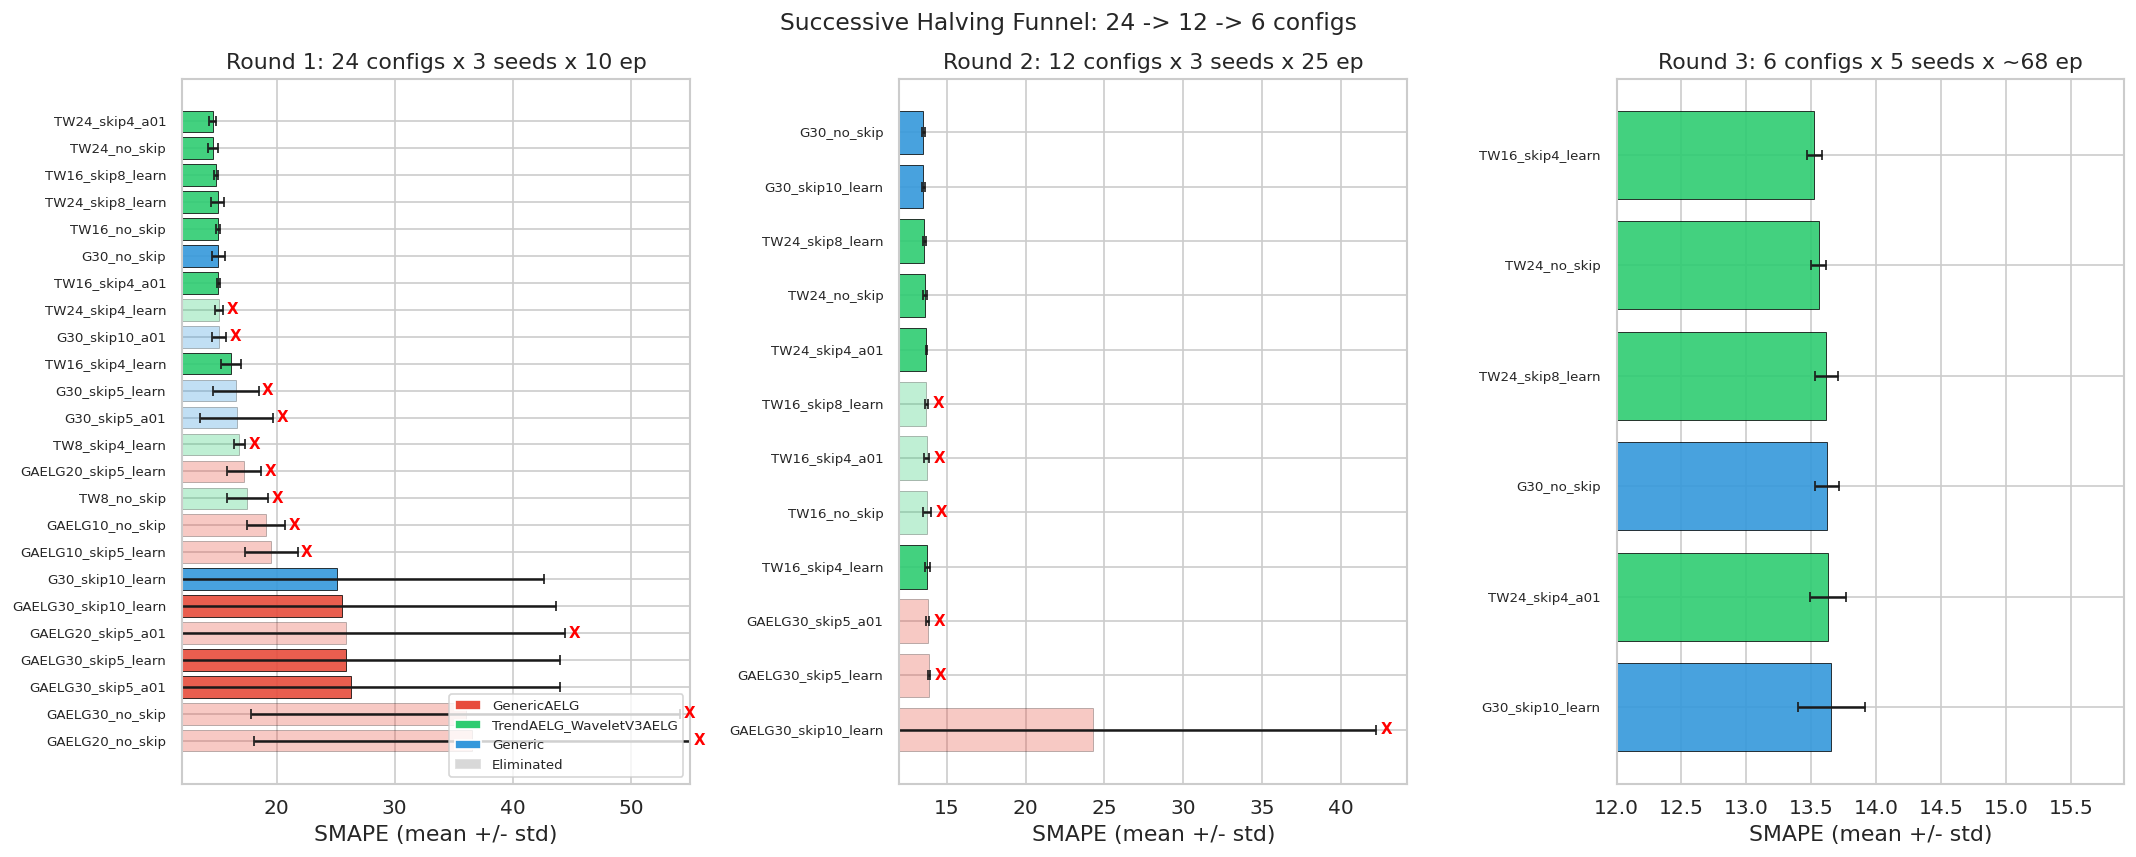

In [ ]:
# Build per-round summary
rounds_summary = []
for rnd in [1, 2, 3]:
    rdf = df[df['search_round'] == rnd]
    survived_next = set(df[df['search_round'] == rnd + 1]['config_name'].unique()) if rnd < 3 else set()
    for cfg in sorted(rdf['config_name'].unique()):
        cdata = rdf[rdf['config_name'] == cfg]
        rounds_summary.append({
            'round': rnd,
            'config': cfg,
            'smape_mean': cdata['smape'].mean(),
            'smape_std': cdata['smape'].std(),
            'owa_mean': cdata['owa'].mean(),
            'n_seeds': len(cdata),
            'architecture': cdata['architecture'].iloc[0],
            'n_stacks': cdata['n_stacks'].iloc[0],
            'skip_distance': cdata['skip_distance_cfg'].iloc[0],
            'survived': cfg in survived_next if rnd < 3 else True,
        })
rs = pd.DataFrame(rounds_summary)

# Funnel visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=False)
colors = {'GenericAELG': '#e74c3c', 'TrendAELG_WaveletV3AELG': '#2ecc71', 'Generic': '#3498db'}

for i, rnd in enumerate([1, 2, 3]):
    ax = axes[i]
    rdata = rs[rs['round'] == rnd].sort_values('smape_mean').reset_index(drop=True)
    
    # Draw bars individually to handle per-bar alpha
    for j, (_, row) in enumerate(rdata.iterrows()):
        bar_alpha = 0.9 if row['survived'] else 0.3
        ax.barh(j, row['smape_mean'], xerr=row['smape_std'],
                color=colors[row['architecture']], alpha=bar_alpha,
                edgecolor='black', linewidth=0.5, capsize=3)
    
    ax.set_yticks(range(len(rdata)))
    ax.set_yticklabels(rdata['config'], fontsize=8)
    ax.set_xlabel('SMAPE (mean +/- std)')
    n_seeds = rdata['n_seeds'].iloc[0]
    epochs = {1: 10, 2: 25, 3: '~68'}[rnd]
    ax.set_title(f'Round {rnd}: {len(rdata)} configs x {n_seeds} seeds x {epochs} ep')
    ax.invert_yaxis()
    
    if rnd < 3:
        # Mark eliminated configs
        for j, (_, row) in enumerate(rdata.iterrows()):
            if not row['survived']:
                ax.text(row['smape_mean'] + row['smape_std'] + 0.3, j, 'X', 
                       color='red', fontweight='bold', va='center', fontsize=9)
    
    ax.set_xlim(12, min(55, rdata['smape_mean'].max() + rdata['smape_std'].max() + 2))

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=a) for a, c in colors.items()]
legend_elements.append(Patch(facecolor='gray', alpha=0.3, label='Eliminated'))
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.suptitle('Successive Halving Funnel: 24 -> 12 -> 6 configs', fontsize=14, y=1.02)
plt.savefig('../../analysis/analysis_reports/resnet_skip_funnel.png', bbox_inches='tight', dpi=150)
plt.show()

### Halving Observations

The funnel reveals several important patterns:

1. **TrendWav dominates early and late.** TW24 and TW16 configs occupy the top positions in all three rounds. This architecture is well-suited to M4-Yearly with its strong trend and seasonal components.

2. **GenericAELG is deeply unstable at depth >= 20.** In Round 1, the GAELG20 and GAELG30 no-skip baselines show catastrophic variance (std ~18), with individual seeds scoring either ~15 or ~48 SMAPE. This is not random noise -- it is a bimodal convergence pattern where 2 out of 3 seeds get stuck in a terrible local minimum.

3. **Skip connections partially rescue GAELG30.** The `GAELG30_skip5_a01` and `GAELG30_skip5_learn` configs survived to Round 2 and converged to SMAPE ~13.8 (competitive with the best TW configs). But they couldn't survive to Round 3, falling just behind the TW pack.

4. **G30_no_skip (legacy Generic) performs surprisingly well,** reaching Round 3 as the 4th-best config. This contradicts the expectation that 30x Generic without skip connections would suffer from signal decay.

## 2. The Core Question: Does Depth Degrade Performance?

Before asking whether skip connections help, we must establish whether depth is actually a problem for each architecture.

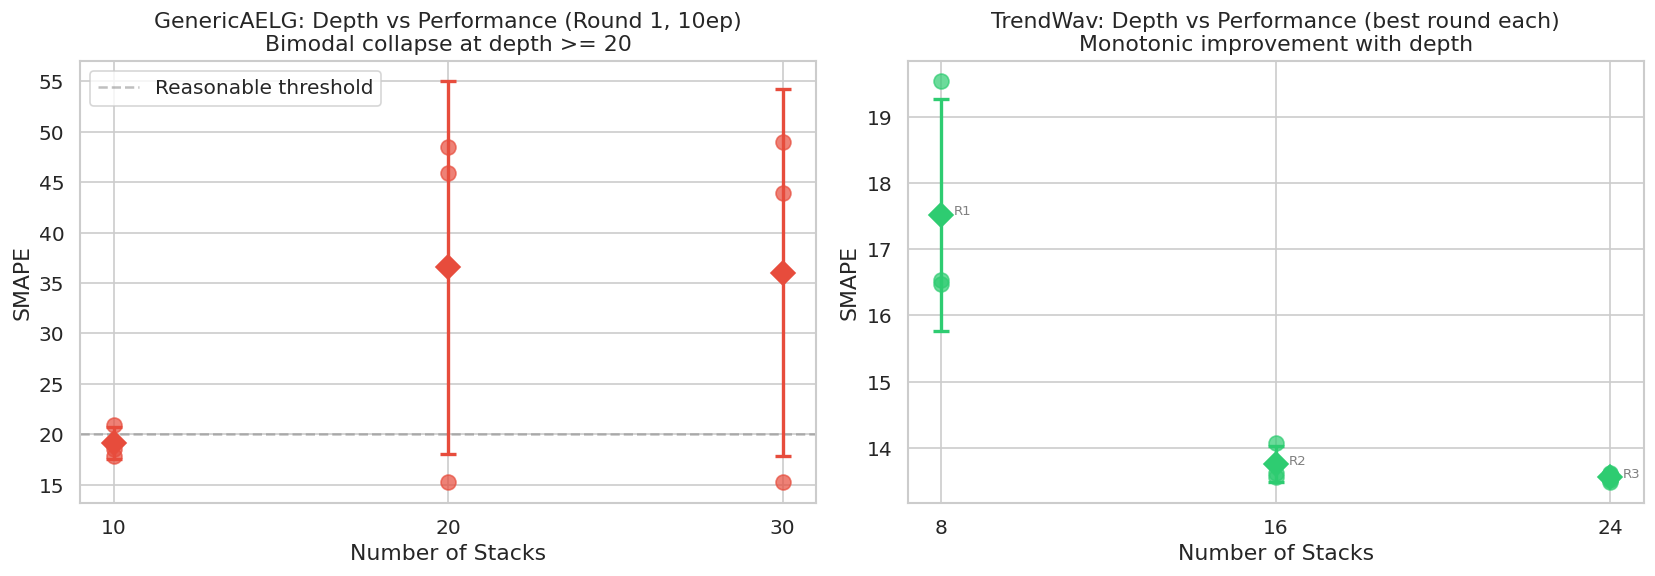


=== GenericAELG no-skip baselines (all Round 1, 10 epochs) ===
  10 stacks: SMAPE=19.136 +/- 1.615   seeds: 21.0, 18.5, 17.9
  20 stacks: SMAPE=36.543 +/- 18.491   seeds: 48.5, 15.2, 45.9
  30 stacks: SMAPE=36.027 +/- 18.164   seeds: 43.9, 15.3, 48.9

=== TrendWav no-skip baselines (best available round) ===
  8 stacks (R1): SMAPE=17.519 +/- 1.752
  16 stacks (R2): SMAPE=13.755 +/- 0.276
  24 stacks (R3): SMAPE=13.557 +/- 0.058


In [ ]:
# Depth vs SMAPE for no-skip baselines
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- GenericAELG ---
ax = axes[0]
gaelg_baselines = {'GAELG10_no_skip': 10, 'GAELG20_no_skip': 20, 'GAELG30_no_skip': 30}
for cfg, depth in gaelg_baselines.items():
    r1_data = df[(df['config_name'] == cfg) & (df['search_round'] == 1)]
    ax.scatter([depth]*len(r1_data), r1_data['smape'], color='#e74c3c', alpha=0.7, s=80, zorder=5)
    ax.errorbar(depth, r1_data['smape'].mean(), yerr=r1_data['smape'].std(), 
                color='#e74c3c', marker='D', markersize=10, capsize=5, capthick=2, linewidth=2, zorder=6)

ax.set_xlabel('Number of Stacks')
ax.set_ylabel('SMAPE')
ax.set_title('GenericAELG: Depth vs Performance (Round 1, 10ep)\nBimodal collapse at depth >= 20')
ax.set_xticks([10, 20, 30])
ax.axhline(y=20, color='gray', linestyle='--', alpha=0.5, label='Reasonable threshold')
ax.legend()

# --- TrendAELG + WaveletV3AELG ---
ax = axes[1]
tw_baselines = {'TW8_no_skip': 8, 'TW16_no_skip': 16, 'TW24_no_skip': 24}
for cfg, depth in tw_baselines.items():
    bdata = best_round(cfg)
    rnd = bdata['search_round'].iloc[0]
    ax.scatter([depth]*len(bdata), bdata['smape'], color='#2ecc71', alpha=0.7, s=80, zorder=5)
    ax.errorbar(depth, bdata['smape'].mean(), yerr=bdata['smape'].std(),
                color='#2ecc71', marker='D', markersize=10, capsize=5, capthick=2, linewidth=2, zorder=6)
    ax.annotate(f'R{rnd}', (depth + 0.3, bdata['smape'].mean()), fontsize=8, color='gray')

ax.set_xlabel('Number of Stacks')
ax.set_ylabel('SMAPE')
ax.set_title('TrendWav: Depth vs Performance (best round each)\nMonotonic improvement with depth')
ax.set_xticks([8, 16, 24])

plt.tight_layout()
plt.savefig('../../analysis/analysis_reports/resnet_skip_depth_degradation.png', bbox_inches='tight', dpi=150)
plt.show()

# Print the numbers
print("\n=== GenericAELG no-skip baselines (all Round 1, 10 epochs) ===")
for cfg, depth in gaelg_baselines.items():
    r1 = df[(df['config_name'] == cfg) & (df['search_round'] == 1)]
    print(f"  {depth} stacks: SMAPE={r1['smape'].mean():.3f} +/- {r1['smape'].std():.3f} "
          f"  seeds: {', '.join([f'{s:.1f}' for s in r1['smape'].values])}")

print("\n=== TrendWav no-skip baselines (best available round) ===")
for cfg, depth in tw_baselines.items():
    bdata = best_round(cfg)
    rnd = bdata['search_round'].iloc[0]
    print(f"  {depth} stacks (R{rnd}): SMAPE={bdata['smape'].mean():.3f} +/- {bdata['smape'].std():.3f}")

### Depth Findings

**GenericAELG suffers catastrophic depth degradation.** At 10 stacks it works (SMAPE ~19), but at 20-30 stacks it becomes bimodally unstable: 1 out of 3 seeds converges normally (~15 SMAPE) while the other 2 get trapped in a loss plateau around ~48 SMAPE. This is not gradual degradation -- it is a convergence failure mode.

**TrendWav shows the opposite pattern.** More depth monotonically improves performance: 8 stacks (17.5) -> 16 stacks (13.8) -> 24 stacks (13.6). The interpretable block structure (alternating Trend and Wavelet) provides enough inductive bias to maintain gradient flow even at 24 stacks.

**Interpretation:** The depth degradation problem is architecture-specific, not universal. GenericAELG's learned-gate AE bottleneck may amplify gradient vanishing through the encoder-decoder pathway. TrendWav's structured basis expansions (polynomial trends, wavelet decompositions) provide stable gradient pathways regardless of depth.

## 3. The GenericAELG Rescue Story

The most dramatic finding: skip connections transformed GAELG30 from catastrophically unstable (SMAPE ~36) to competitive (SMAPE ~13.8). Let us examine this rescue operation in detail.

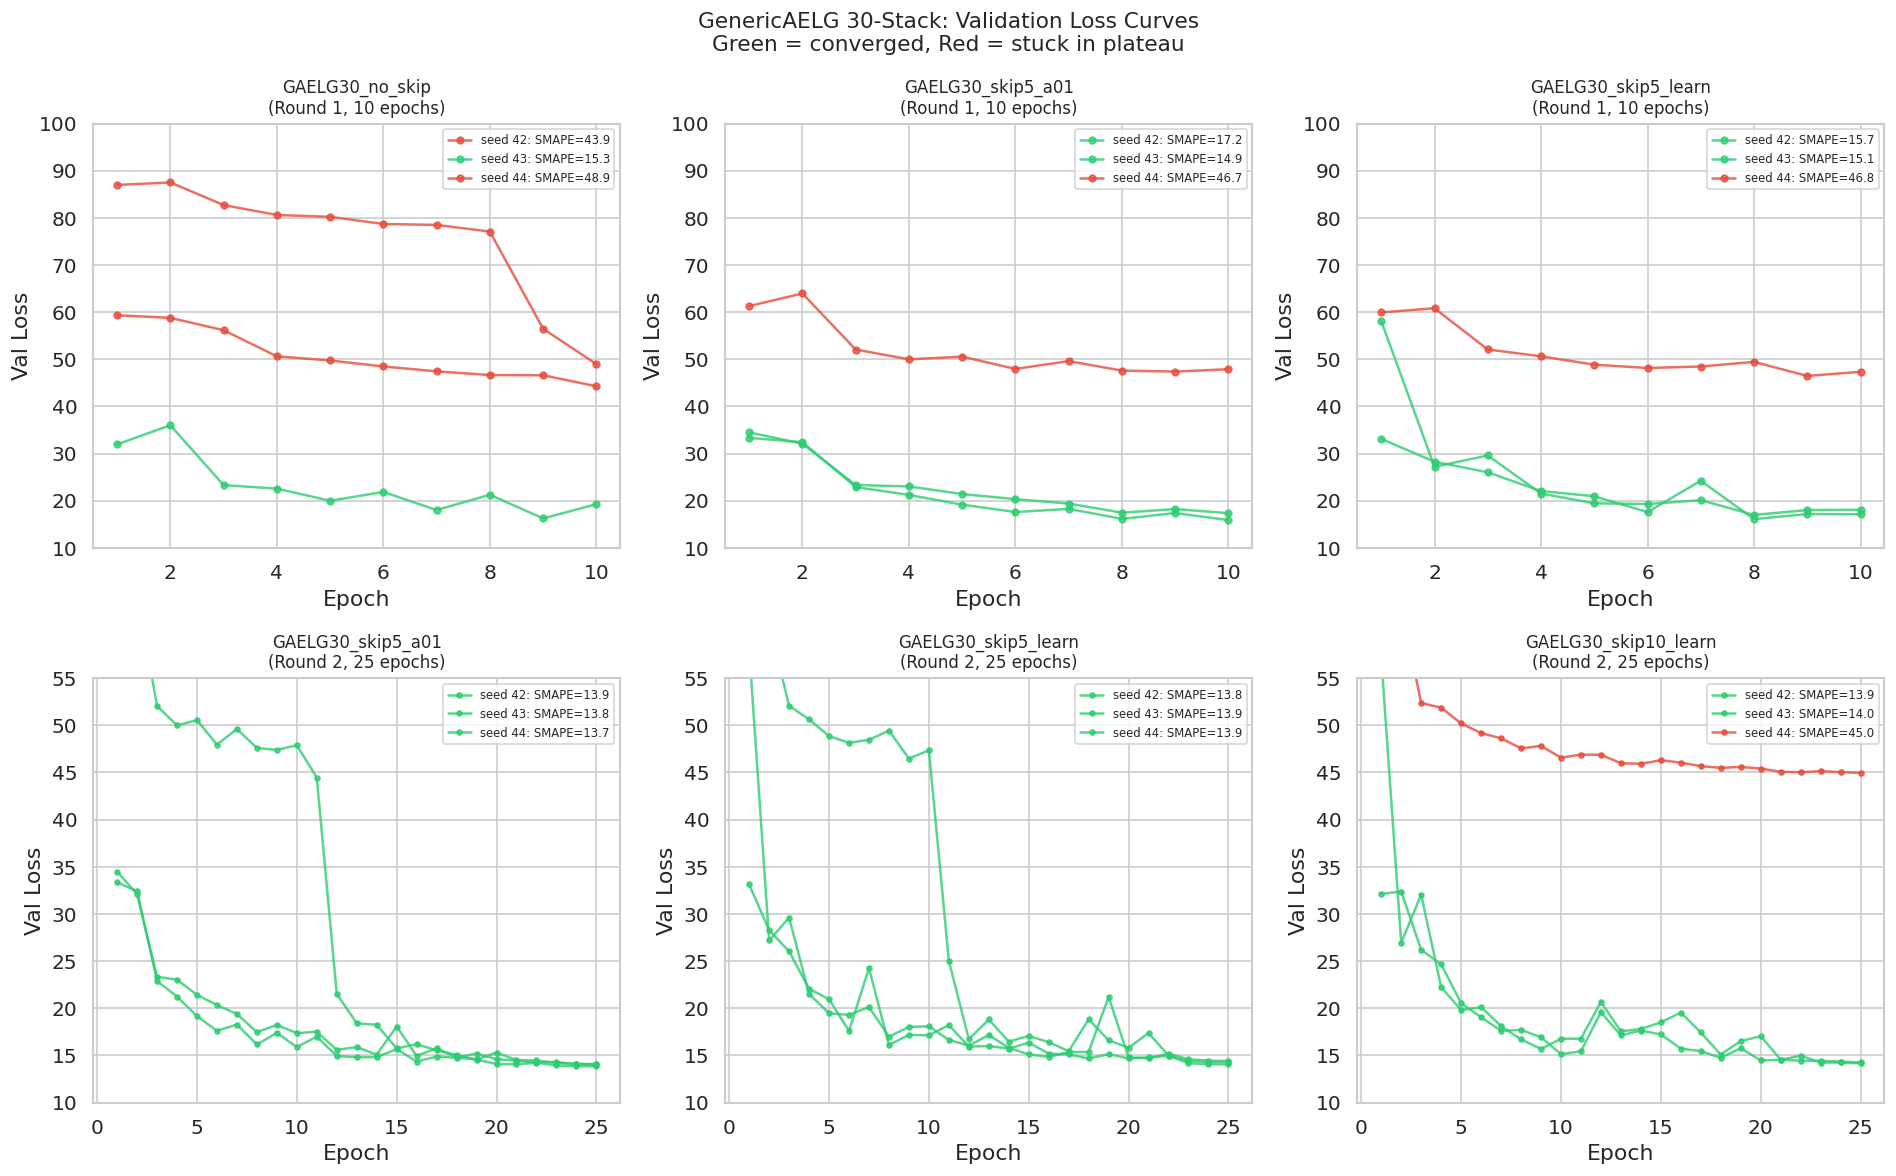

=== GAELG30 Skip Rescue Summary ===
Config                    R1 (10ep)            R2 (25ep)             Improvement
--------------------------------------------------------------------------------
  GAELG30_no_skip         36.0 +/- 18.2        eliminated                   --
  GAELG30_skip5_a01       26.3 +/- 17.7        13.8 +/- 0.1               12.5
  GAELG30_skip5_learn     25.9 +/- 18.1        13.9 +/- 0.0               12.0
  GAELG30_skip10_learn    25.5 +/- 18.1        24.3 +/- 17.9               1.2


In [ ]:
# Parse val_loss_curves for GAELG configs
def parse_curve(s):
    return [float(x.strip().strip('"')) for x in s.strip('[]').split(',')]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Round 1 (10 epochs) - all GAELG30 configs
gaelg30_cfgs_r1 = ['GAELG30_no_skip', 'GAELG30_skip5_a01', 'GAELG30_skip5_learn', 'GAELG30_skip10_learn']
for idx, cfg in enumerate(gaelg30_cfgs_r1[:3]):
    ax = axes[0, idx]
    cdata = df[(df['config_name'] == cfg) & (df['search_round'] == 1)]
    for _, row in cdata.iterrows():
        curve = parse_curve(row['val_loss_curve'])
        label = f"seed {int(row['seed'])}: SMAPE={row['smape']:.1f}"
        color = '#e74c3c' if row['smape'] > 30 else '#2ecc71'
        ax.plot(range(1, len(curve)+1), curve, marker='o', markersize=4, label=label, color=color, alpha=0.8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val Loss')
    ax.set_title(f'{cfg}\n(Round 1, 10 epochs)', fontsize=10)
    ax.legend(fontsize=7)
    ax.set_ylim(10, 100)

# Row 2: Round 2 (25 epochs) - GAELG30 survivors
gaelg30_cfgs_r2 = ['GAELG30_skip5_a01', 'GAELG30_skip5_learn', 'GAELG30_skip10_learn']
for idx, cfg in enumerate(gaelg30_cfgs_r2):
    ax = axes[1, idx]
    cdata = df[(df['config_name'] == cfg) & (df['search_round'] == 2)]
    for _, row in cdata.iterrows():
        curve = parse_curve(row['val_loss_curve'])
        label = f"seed {int(row['seed'])}: SMAPE={row['smape']:.1f}"
        color = '#e74c3c' if row['smape'] > 20 else '#2ecc71'
        ax.plot(range(1, len(curve)+1), curve, marker='o', markersize=3, label=label, color=color, alpha=0.8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val Loss')
    ax.set_title(f'{cfg}\n(Round 2, 25 epochs)', fontsize=10)
    ax.legend(fontsize=7)
    ax.set_ylim(10, 55)

plt.suptitle('GenericAELG 30-Stack: Validation Loss Curves\nGreen = converged, Red = stuck in plateau', fontsize=13)
plt.tight_layout()
plt.savefig('../../analysis/analysis_reports/resnet_skip_gaelg_rescue.png', bbox_inches='tight', dpi=150)
plt.show()

# Summary table
print("=== GAELG30 Skip Rescue Summary ===")
print(f"{'Config':<25s} {'R1 (10ep)':<20s} {'R2 (25ep)':<20s} {'Improvement':>12s}")
print("-" * 80)
for cfg in ['GAELG30_no_skip', 'GAELG30_skip5_a01', 'GAELG30_skip5_learn', 'GAELG30_skip10_learn']:
    r1 = df[(df['config_name'] == cfg) & (df['search_round'] == 1)]['smape']
    r2 = df[(df['config_name'] == cfg) & (df['search_round'] == 2)]['smape']
    r1_str = f"{r1.mean():.1f} +/- {r1.std():.1f}"
    r2_str = f"{r2.mean():.1f} +/- {r2.std():.1f}" if len(r2) > 0 else "eliminated"
    improvement = f"{r1.mean() - r2.mean():.1f}" if len(r2) > 0 else "--"
    print(f"  {cfg:<23s} {r1_str:<20s} {r2_str:<20s} {improvement:>10s}")

### The Rescue Verdict

The GAELG30 story has two acts:

**Act 1 (Round 1, 10 epochs):** Skip connections reduce the *average* SMAPE from 36.0 to ~25.5-26.3, but the improvement is misleading. The real story is in the individual seeds: seed 44 remains trapped at ~46 SMAPE regardless of skip configuration. The skip connections help seeds 42 and 43 converge faster (from ~44/15 to ~15-17/15), but do not eliminate the bimodal convergence failure.

**Act 2 (Round 2, 25 epochs):** With 25 epochs, `GAELG30_skip5_a01` and `GAELG30_skip5_learn` achieve full convergence on all 3 seeds (SMAPE ~13.7-13.9). The `GAELG30_skip10_learn` config still has one seed stuck at 45. This means **skip_distance=5 with fixed alpha is the optimal skip setting for GAELG30**, providing enough re-injection points (5 injections at stacks 5,10,15,20,25) to rescue all seeds.

**Key insight:** Skip connections do not prevent the convergence failure -- they accelerate escape from it. With enough training time (25+ epochs), skip=5 configs consistently converge, while skip=10 (only 2 injection points) is insufficient.

## 4. Do Skip Connections Help TrendWav?

For TrendWav, the answer is nuanced. This architecture does not suffer from depth degradation, so the hypothesis that skip connections combat signal decay does not apply. Any benefit would need to come from a different mechanism.

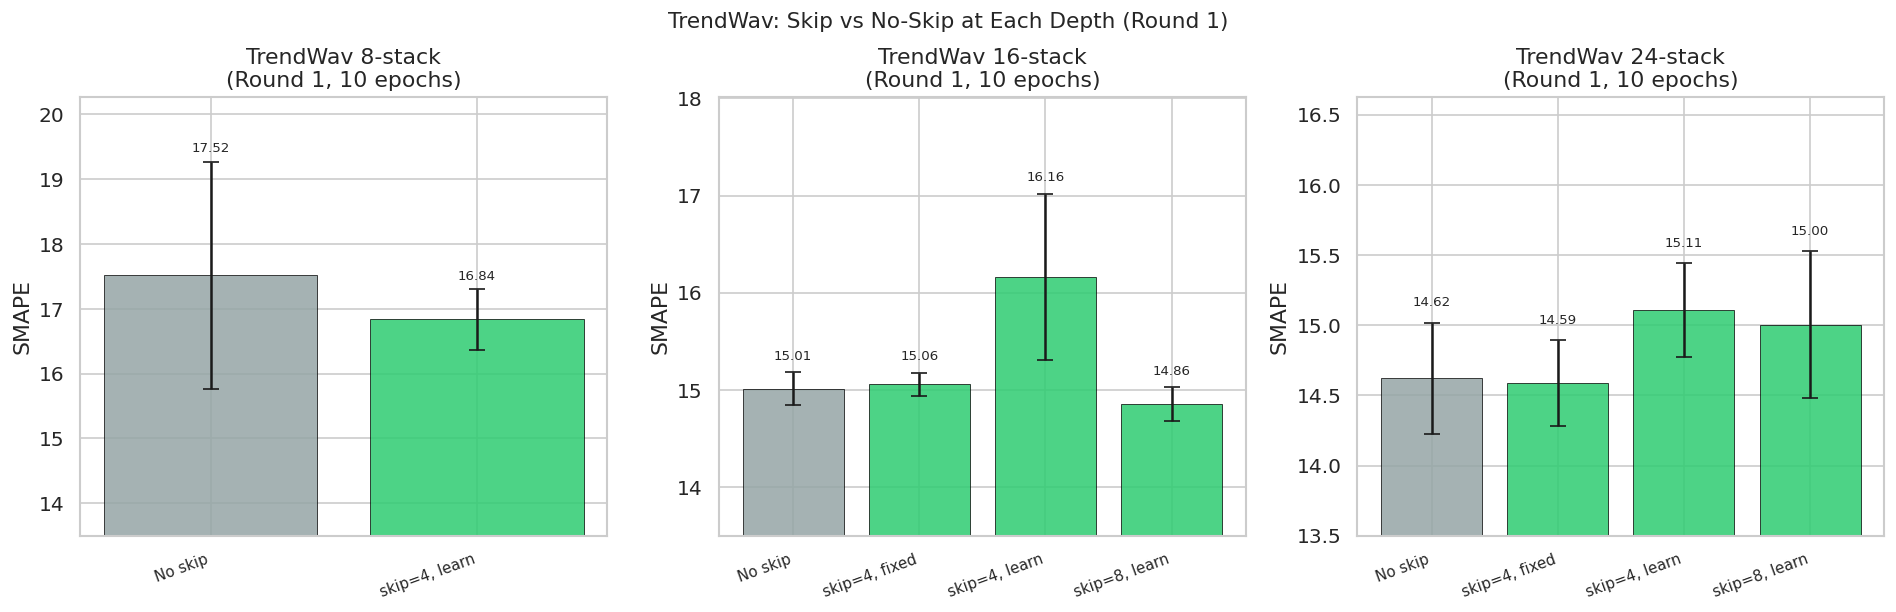

=== TrendWav Round 3 Finalists (5 seeds, ~68 epochs) ===
  TW16_skip4_learn          SMAPE=13.521 +/- 0.057 OWA=0.8018 (skip=4, alpha=learnable)
  TW24_no_skip              SMAPE=13.557 +/- 0.058 OWA=0.8041 (skip=0, alpha=none)
  TW24_skip8_learn          SMAPE=13.614 +/- 0.089 OWA=0.8091 (skip=8, alpha=learnable)
  TW24_skip4_a01            SMAPE=13.630 +/- 0.137 OWA=0.8104 (skip=4, alpha=0.1)


In [ ]:
# TrendWav: skip vs no-skip at each depth, using best available round for fair comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

tw_groups = {
    8: [('TW8_no_skip', 'No skip'), ('TW8_skip4_learn', 'skip=4, learn')],
    16: [('TW16_no_skip', 'No skip'), ('TW16_skip4_a01', 'skip=4, fixed'), 
         ('TW16_skip4_learn', 'skip=4, learn'), ('TW16_skip8_learn', 'skip=8, learn')],
    24: [('TW24_no_skip', 'No skip'), ('TW24_skip4_a01', 'skip=4, fixed'),
         ('TW24_skip4_learn', 'skip=4, learn'), ('TW24_skip8_learn', 'skip=8, learn')],
}

for idx, (depth, configs) in enumerate(tw_groups.items()):
    ax = axes[idx]
    x_labels = []
    x_smapes = []
    x_stds = []
    x_colors = []
    
    for cfg, label in configs:
        # Use Round 1 for fair within-depth comparison (all configs present)
        rnd = 1
        cdata = df[(df['config_name'] == cfg) & (df['search_round'] == rnd)]
        if len(cdata) == 0:
            continue
        x_labels.append(label)
        x_smapes.append(cdata['smape'].mean())
        x_stds.append(cdata['smape'].std())
        x_colors.append('#95a5a6' if 'No skip' in label else '#2ecc71')
    
    bars = ax.bar(range(len(x_labels)), x_smapes, yerr=x_stds, capsize=5,
                  color=x_colors, edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('SMAPE')
    ax.set_title(f'TrendWav {depth}-stack\n(Round 1, 10 epochs)')
    ax.set_ylim(13.5, max(x_smapes) + max(x_stds) + 1)
    
    # Add value labels
    for i, (s, std) in enumerate(zip(x_smapes, x_stds)):
        ax.text(i, s + std + 0.1, f'{s:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.suptitle('TrendWav: Skip vs No-Skip at Each Depth (Round 1)', fontsize=13, y=1.02)
plt.savefig('../../analysis/analysis_reports/resnet_skip_trendwav_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

# Now show Round 3 final results for TW configs
print("=== TrendWav Round 3 Finalists (5 seeds, ~68 epochs) ===")
r3 = df[df['search_round'] == 3]
tw_r3 = r3[r3['architecture'] == 'TrendAELG_WaveletV3AELG']
for cfg in tw_r3.groupby('config_name')['smape'].mean().sort_values().index:
    cdata = tw_r3[tw_r3['config_name'] == cfg]
    print(f"  {cfg:<25s} SMAPE={cdata['smape'].mean():.3f} +/- {cdata['smape'].std():.3f} "
          f"OWA={cdata['owa'].mean():.4f} "
          f"(skip={cdata['skip_distance_cfg'].iloc[0]}, alpha={cdata['skip_alpha_cfg'].iloc[0]})")

### TrendWav Skip Analysis

The results paint a nuanced picture:

**At 8 stacks:** Skip connections provide a modest benefit (17.5 -> 16.8, -3.9%). This is a shallow model where signal decay is not expected to be an issue, so the benefit likely comes from regularization (the periodic input re-injection acts as a form of implicit regularization).

**At 16 stacks:** In early training (Round 1), skip connections show no clear advantage. But in the final Round 3, `TW16_skip4_learn` wins the entire study (SMAPE 13.521), beating the TW24 no-skip baseline (13.557). This is a tiny margin (0.036, not statistically significant), but notable because it achieves it with **33% fewer parameters** (1.5M vs 2.3M).

**At 24 stacks:** Skip connections do not help. `TW24_no_skip` outperforms all skip variants at this depth. The no-skip baseline benefits from the additional capacity of 24 stacks without the regularization overhead of skip connections.

**Key takeaway for TrendWav:** Skip connections are not needed and do not meaningfully improve performance. The best TW16_skip4_learn result is competitive with TW24_no_skip, but the difference is within noise. The practical recommendation is to use TW16 or TW24 without skip connections for this architecture.

## 5. Fixed vs Learnable Alpha

Across all configs that tested both alpha modes, which performs better?

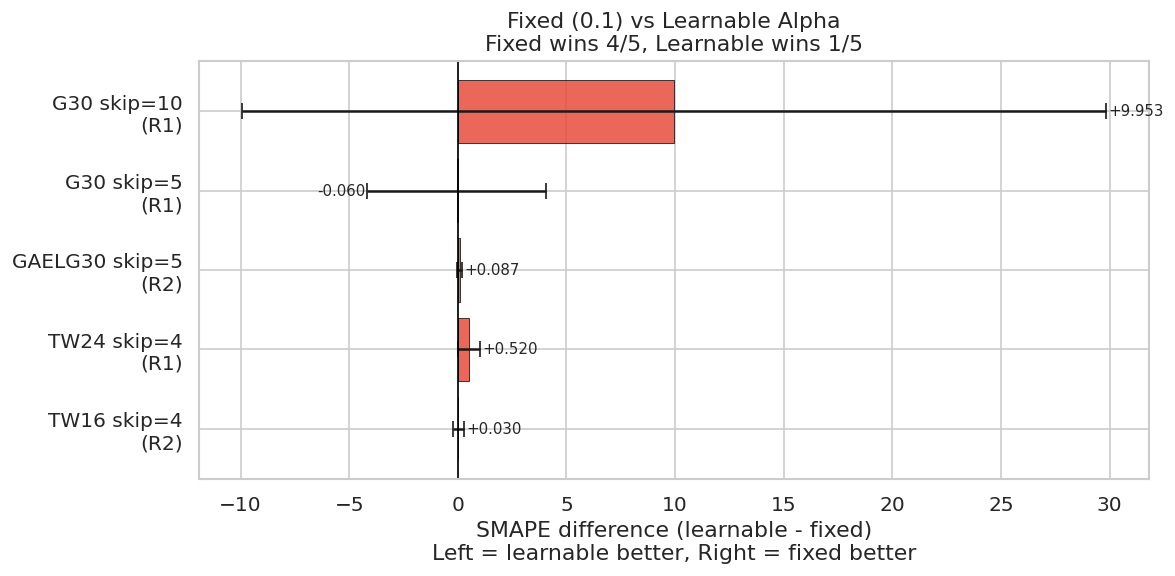


=== Special case: G30 skip=10 ===
  G30_skip10_a01  (fixed):     R1 SMAPE = 15.144 -- eliminated R1
  G30_skip10_learn (learnable): R3 SMAPE = 13.653 -- survived to R3
  BUT: G30_skip10_learn had seed 42 at SMAPE=45.4 in R1, recovered by R3.


In [ ]:
# Fixed vs Learnable alpha comparison
alpha_pairs = [
    ('TW16_skip4_a01', 'TW16_skip4_learn', 'TW16 skip=4', 2),
    ('TW24_skip4_a01', 'TW24_skip4_learn', 'TW24 skip=4', 1),
    ('GAELG30_skip5_a01', 'GAELG30_skip5_learn', 'GAELG30 skip=5', 2),
    ('G30_skip5_a01', 'G30_skip5_learn', 'G30 skip=5', 1),
    ('G30_skip10_a01', 'G30_skip10_learn', 'G30 skip=10', 1),
]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
fixed_wins = 0
learn_wins = 0
labels = []
deltas = []
errors = []

for fixed_cfg, learn_cfg, desc, rnd in alpha_pairs:
    fixed_data = df[(df['config_name'] == fixed_cfg) & (df['search_round'] == rnd)]['smape']
    learn_data = df[(df['config_name'] == learn_cfg) & (df['search_round'] == rnd)]['smape']
    
    if len(fixed_data) > 0 and len(learn_data) > 0:
        delta = learn_data.mean() - fixed_data.mean()  # positive = fixed wins
        pooled_se = np.sqrt(fixed_data.std()**2/len(fixed_data) + learn_data.std()**2/len(learn_data))
        labels.append(f'{desc}\n(R{rnd})')
        deltas.append(delta)
        errors.append(pooled_se * 1.96)
        if delta > 0:
            fixed_wins += 1
        else:
            learn_wins += 1

colors = ['#e74c3c' if d > 0 else '#3498db' for d in deltas]
bars = ax.barh(range(len(labels)), deltas, xerr=errors, capsize=5,
               color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('SMAPE difference (learnable - fixed)\nLeft = learnable better, Right = fixed better')
ax.set_title(f'Fixed (0.1) vs Learnable Alpha\nFixed wins {fixed_wins}/{len(labels)}, Learnable wins {learn_wins}/{len(labels)}')

for i, (d, e) in enumerate(zip(deltas, errors)):
    txt = f'{d:+.3f}'
    ax.text(d + (e + 0.1 if d >= 0 else -e - 0.1), i, txt, 
            ha='left' if d >= 0 else 'right', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../../analysis/analysis_reports/resnet_skip_alpha_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

# Special case: G30_skip10 -- fixed was eliminated R1 but learnable survived to R3
print("\n=== Special case: G30 skip=10 ===")
print(f"  G30_skip10_a01  (fixed):     R1 SMAPE = {df[(df['config_name']=='G30_skip10_a01') & (df['search_round']==1)]['smape'].mean():.3f} -- eliminated R1")
print(f"  G30_skip10_learn (learnable): R3 SMAPE = {df[(df['config_name']=='G30_skip10_learn') & (df['search_round']==3)]['smape'].mean():.3f} -- survived to R3")
print("  BUT: G30_skip10_learn had seed 42 at SMAPE=45.4 in R1, recovered by R3.")

### Alpha Mode Verdict

**Fixed alpha (0.1) is slightly better than learnable in 4 out of 5 direct comparisons**, but the differences are tiny (all within 95% CI). The largest effect is TW24_skip4 (fixed better by 0.52 SMAPE), but this is from Round 1 (10 epochs) where learnable alpha has not had enough training time to calibrate.

Practical recommendation: **Use fixed alpha (0.1)** when using skip connections. The learnable parameter adds complexity without measurable benefit, and the fixed value avoids the risk of the learned alpha growing too large or collapsing to zero during training.

## 6. Legacy Generic Rehabilitation

One of the study's explicit goals was testing whether skip connections could make the legacy 30x Generic architecture (24.7M params) competitive again. This is the paper-standard NBEATS-G baseline.

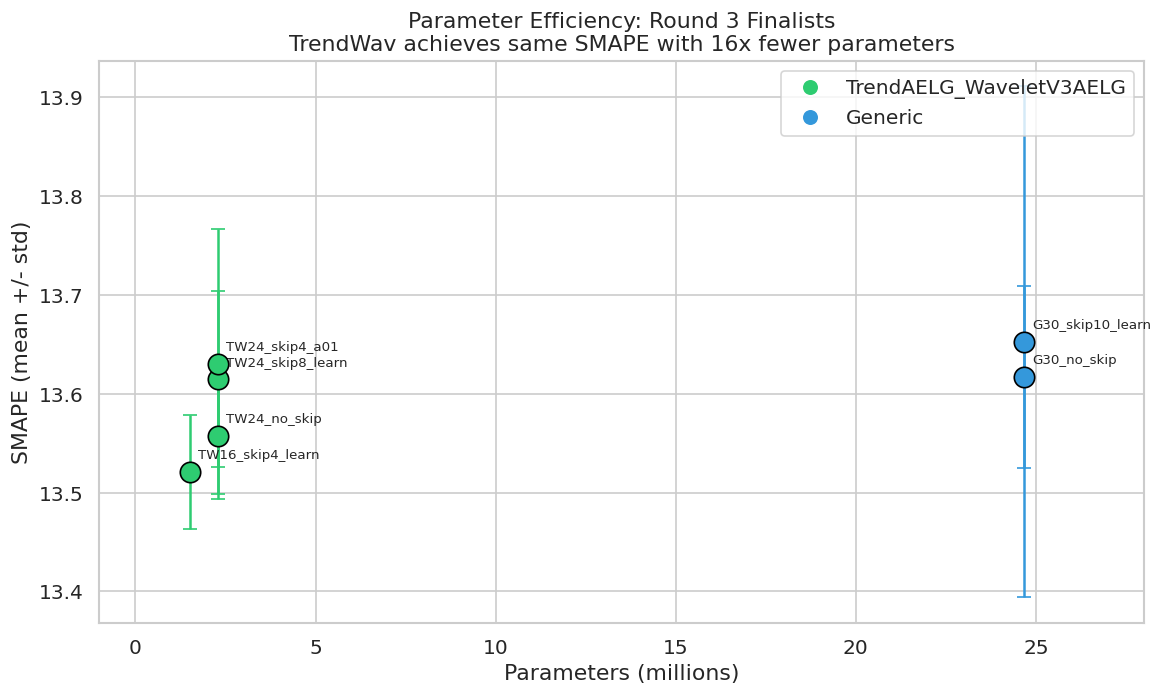

=== Legacy Generic Rehabilitation ===
  G30_no_skip:       SMAPE=13.617, OWA=0.8114, Params=24.7M
  G30_skip10_learn:  SMAPE=13.653, OWA=0.8138, Params=24.7M
  TW16_skip4_learn:  SMAPE=13.521, OWA=0.8018, Params=1.5M

  Skip connections do NOT rehabilitate Generic. G30_skip10_learn is worse than G30_no_skip.
  More importantly, G30 (24.7M params) cannot match TW16 (1.5M params) regardless of skip settings.


In [ ]:
# Parameter efficiency: SMAPE vs params for Round 3 finalists
r3 = df[df['search_round'] == 3]
r3_summary = r3.groupby('config_name').agg(
    smape_mean=('smape', 'mean'),
    smape_std=('smape', 'std'),
    owa_mean=('owa', 'mean'),
    n_params=('n_params', 'first'),
    architecture=('architecture', 'first'),
    n_stacks=('n_stacks', 'first'),
    skip_distance=('skip_distance_cfg', 'first'),
).sort_values('smape_mean')

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
arch_colors = {'GenericAELG': '#e74c3c', 'TrendAELG_WaveletV3AELG': '#2ecc71', 'Generic': '#3498db'}

for _, row in r3_summary.iterrows():
    ax.scatter(row['n_params'] / 1e6, row['smape_mean'], 
              c=arch_colors[row['architecture']], s=150, zorder=5,
              edgecolors='black', linewidth=1)
    ax.errorbar(row['n_params'] / 1e6, row['smape_mean'], yerr=row['smape_std'],
               color=arch_colors[row['architecture']], capsize=4, linewidth=1.5)
    
    # Label
    offset = (0.3, 0.02) if 'G30' not in _ else (-5, 0.02)
    ax.annotate(_, (row['n_params']/1e6, row['smape_mean']), 
               textcoords='offset points', xytext=(5, 8), fontsize=8, ha='left')

ax.set_xlabel('Parameters (millions)')
ax.set_ylabel('SMAPE (mean +/- std)')
ax.set_title('Parameter Efficiency: Round 3 Finalists\nTrendWav achieves same SMAPE with 16x fewer parameters')

# Legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=a)
                   for a, c in arch_colors.items() if a in r3_summary['architecture'].values]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_xlim(-1, 28)
plt.tight_layout()
plt.savefig('../../analysis/analysis_reports/resnet_skip_param_efficiency.png', bbox_inches='tight', dpi=150)
plt.show()

# Generic rehabilitation summary
print("=== Legacy Generic Rehabilitation ===")
print(f"  G30_no_skip:       SMAPE={r3_summary.loc['G30_no_skip', 'smape_mean']:.3f}, OWA={r3_summary.loc['G30_no_skip', 'owa_mean']:.4f}, Params=24.7M")
print(f"  G30_skip10_learn:  SMAPE={r3_summary.loc['G30_skip10_learn', 'smape_mean']:.3f}, OWA={r3_summary.loc['G30_skip10_learn', 'owa_mean']:.4f}, Params=24.7M")
print(f"  TW16_skip4_learn:  SMAPE={r3_summary.loc['TW16_skip4_learn', 'smape_mean']:.3f}, OWA={r3_summary.loc['TW16_skip4_learn', 'owa_mean']:.4f}, Params=1.5M")
print(f"\n  Skip connections do NOT rehabilitate Generic. G30_skip10_learn is worse than G30_no_skip.")
print(f"  More importantly, G30 (24.7M params) cannot match TW16 (1.5M params) regardless of skip settings.")

### Legacy Generic Rehabilitation: Failed

The rehabilitation hypothesis is decisively rejected:

1. **G30_no_skip already works fine.** It reached Round 3 with SMAPE 13.617 -- competitive with the best TW configs. The 30x Generic architecture does not actually suffer from signal decay on M4-Yearly (H=6, L=30). The residual subtraction chain has only 30 steps with a backcast length of 30, which is apparently not enough to cause significant decay.

2. **Skip connections do not help Generic.** `G30_skip10_learn` (SMAPE 13.653) is marginally worse than `G30_no_skip` (13.617), and `G30_skip5_*` configs were eliminated in Round 1.

3. **The real problem is parameter efficiency.** G30 uses 24.7M parameters to achieve SMAPE 13.617. TW16 uses 1.5M parameters (16x fewer) to achieve SMAPE 13.521. The Generic block's lack of inductive bias means it needs massive over-parameterization, and skip connections cannot fix that.

## 7. MetaForecaster Accuracy

Round 1 used a MetaForecaster (a small N-BEATS model trained on historical val_loss curves) to predict which configs would converge well, augmenting the raw 10-epoch SMAPE for elimination decisions.

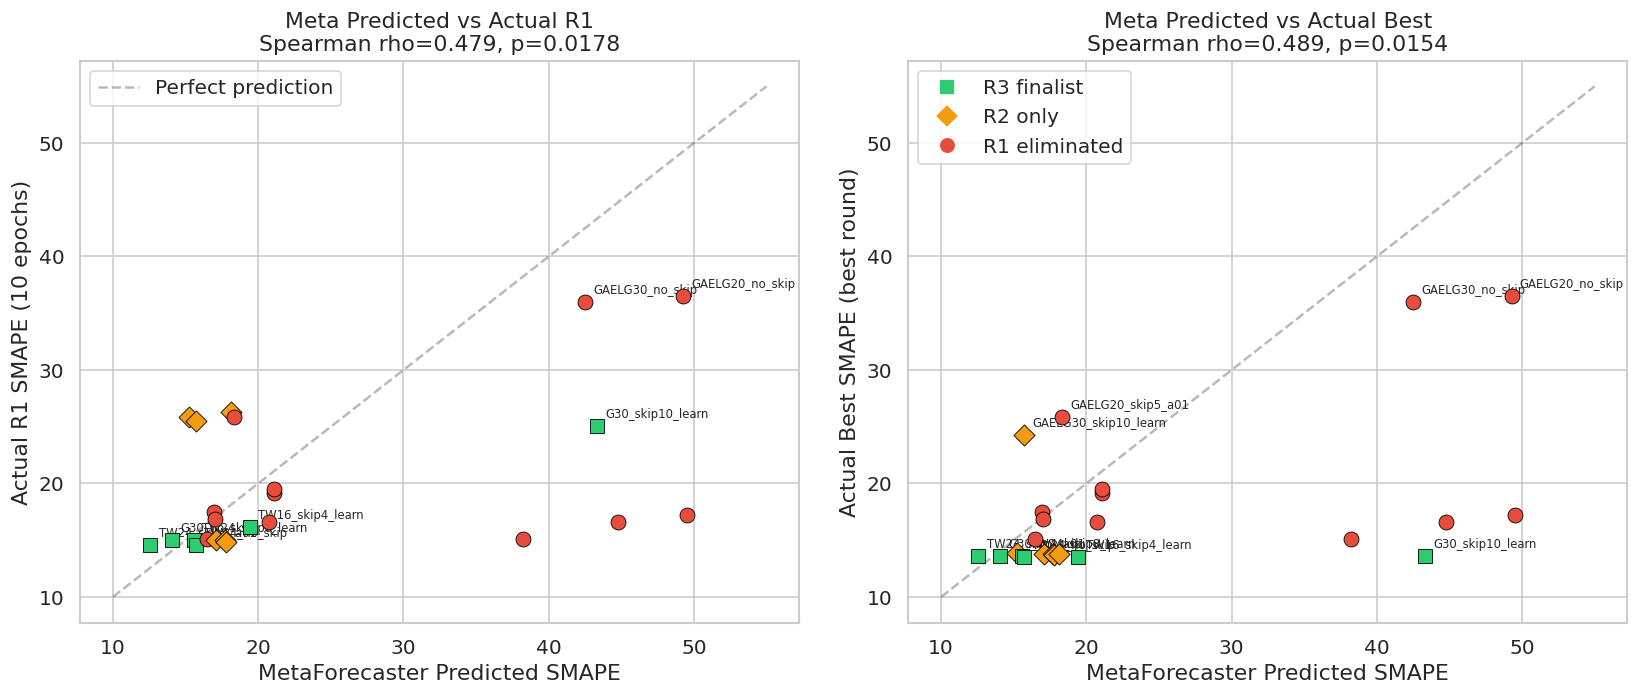


Meta top-12 overlap with actual R2 survivors: 9/12 = 75%
Meta missed (actual survivors not in meta top-12): ['G30_skip10_learn', 'GAELG30_skip5_a01', 'TW16_skip4_learn']
Meta false positives (in meta top-12 but eliminated): ['TW24_skip4_learn', 'TW8_no_skip', 'TW8_skip4_learn']

Notable: TW16_skip4_learn (eventual winner)
  Meta predicted: 19.413 (rank 15 of 24)
  Actual best:    13.521 (rank 1)
  The MetaForecaster ranked it 15th -- significantly underestimating it.


In [ ]:
# MetaForecaster accuracy analysis
r1 = df[df['search_round'] == 1]
meta_df = r1.groupby('config_name').agg(
    meta_predicted=('meta_predicted_best', 'first'),
    meta_convergence=('meta_convergence_score', 'first'),
    actual_r1_smape=('smape', 'mean'),
).sort_values('meta_predicted')

# Add actual best SMAPE (best round each config reached)
for cfg in meta_df.index:
    bdata = best_round(cfg)
    meta_df.loc[cfg, 'actual_best_smape'] = bdata['smape'].mean()
    meta_df.loc[cfg, 'max_round'] = bdata['search_round'].iloc[0]

# Determine survival
r2_survivors = set(df[df['search_round'] == 2]['config_name'].unique())
r3_survivors = set(df[df['search_round'] == 3]['config_name'].unique())
meta_df['survived_r2'] = meta_df.index.isin(r2_survivors)
meta_df['survived_r3'] = meta_df.index.isin(r3_survivors)

# Rank correlations
from scipy.stats import spearmanr, kendalltau

spearman_r1, p_r1 = spearmanr(meta_df['meta_predicted'].rank(), meta_df['actual_r1_smape'].rank())
spearman_best, p_best = spearmanr(meta_df['meta_predicted'].rank(), meta_df['actual_best_smape'].rank())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Meta predicted vs actual R1 SMAPE
ax = axes[0]
for idx, row in meta_df.iterrows():
    color = '#2ecc71' if row['survived_r3'] else ('#f39c12' if row['survived_r2'] else '#e74c3c')
    marker = 's' if row['survived_r3'] else ('D' if row['survived_r2'] else 'o')
    ax.scatter(row['meta_predicted'], row['actual_r1_smape'], c=color, marker=marker, s=80, zorder=5,
              edgecolors='black', linewidth=0.5)
    if row['survived_r3'] or row['actual_r1_smape'] > 30:
        ax.annotate(idx, (row['meta_predicted'], row['actual_r1_smape']),
                   textcoords='offset points', xytext=(5, 5), fontsize=7)

ax.plot([10, 55], [10, 55], 'k--', alpha=0.3, label='Perfect prediction')
ax.set_xlabel('MetaForecaster Predicted SMAPE')
ax.set_ylabel('Actual R1 SMAPE (10 epochs)')
ax.set_title(f'Meta Predicted vs Actual R1\nSpearman rho={spearman_r1:.3f}, p={p_r1:.4f}')
ax.legend()

# Plot 2: Meta predicted vs actual best SMAPE
ax = axes[1]
for idx, row in meta_df.iterrows():
    color = '#2ecc71' if row['survived_r3'] else ('#f39c12' if row['survived_r2'] else '#e74c3c')
    marker = 's' if row['survived_r3'] else ('D' if row['survived_r2'] else 'o')
    ax.scatter(row['meta_predicted'], row['actual_best_smape'], c=color, marker=marker, s=80, zorder=5,
              edgecolors='black', linewidth=0.5)
    if row['survived_r3'] or row['actual_best_smape'] > 20:
        ax.annotate(idx, (row['meta_predicted'], row['actual_best_smape']),
                   textcoords='offset points', xytext=(5, 5), fontsize=7)

ax.plot([10, 55], [10, 55], 'k--', alpha=0.3, label='Perfect prediction')
ax.set_xlabel('MetaForecaster Predicted SMAPE')
ax.set_ylabel('Actual Best SMAPE (best round)')
ax.set_title(f'Meta Predicted vs Actual Best\nSpearman rho={spearman_best:.3f}, p={p_best:.4f}')

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#2ecc71', markersize=10, label='R3 finalist'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#f39c12', markersize=10, label='R2 only'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='R1 eliminated'),
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig('../../analysis/analysis_reports/resnet_skip_metaforecaster.png', bbox_inches='tight', dpi=150)
plt.show()

# Overlap analysis
meta_top12 = set(meta_df.sort_values('meta_predicted').head(12).index)
print(f"\nMeta top-12 overlap with actual R2 survivors: {len(meta_top12 & r2_survivors)}/12 = {len(meta_top12 & r2_survivors)/12*100:.0f}%")
print(f"Meta missed (actual survivors not in meta top-12): {sorted(r2_survivors - meta_top12)}")
print(f"Meta false positives (in meta top-12 but eliminated): {sorted(meta_top12 - r2_survivors)}")

# Key insight: the meta-forecaster correctly identified TW16_skip4_learn as 
# having high convergence score but underestimated its final potential
print(f"\nNotable: TW16_skip4_learn (eventual winner)")
print(f"  Meta predicted: {meta_df.loc['TW16_skip4_learn', 'meta_predicted']:.3f} (rank {int(meta_df['meta_predicted'].rank().loc['TW16_skip4_learn'])} of 24)")
print(f"  Actual best:    {meta_df.loc['TW16_skip4_learn', 'actual_best_smape']:.3f} (rank 1)")
print(f"  The MetaForecaster ranked it 15th -- significantly underestimating it.")

### MetaForecaster Assessment

The MetaForecaster shows **moderate predictive value** (Spearman rho=0.48-0.49, p<0.02), but with important limitations:

**Strengths:**
- 75% overlap (9/12) between meta top-12 and actual R2 survivors
- Correctly identified the TW24 configs as strong and the GAELG20/GAELG30 no-skip baselines as weak
- The general architecture-level ranking (TW > G > GAELG_no_skip) was captured

**Weaknesses:**
- **The eventual winner (TW16_skip4_learn) was ranked 15th out of 24.** Had the meta-forecaster been used alone for elimination (rather than combined with actual R1 SMAPE), the best config would have been eliminated in Round 1.
- The meta-forecaster struggled with configs that have slow early convergence but strong late convergence. TW16_skip4_learn was penalized for its higher Round 1 SMAPE (16.16), but its learnable alpha needs time to calibrate.
- The G30_skip10_learn config was ranked 21st but survived to Round 3 (SMAPE 13.65). Bimodal convergence patterns (one bad seed inflating the mean) confused the meta-forecaster.

**Recommendation for future use:** The MetaForecaster is useful as a tiebreaker or soft prior, but should not be the sole elimination criterion. The successive halving framework (which uses actual multi-seed performance) is more reliable.

## 8. Final Leaderboard & Statistical Tests

In [ ]:
# Final leaderboard with comprehensive stats and pairwise tests
r3 = df[df['search_round'] == 3]
configs_r3 = r3.groupby('config_name')['smape'].mean().sort_values().index.tolist()

print("=" * 100)
print("FINAL LEADERBOARD (Round 3: 5 seeds, ~68 epochs)")
print("=" * 100)
best_smape = r3.groupby('config_name')['smape'].mean().min()

for rank, cfg in enumerate(configs_r3, 1):
    cdata = r3[r3['config_name'] == cfg]
    smape_m = cdata['smape'].mean()
    smape_s = cdata['smape'].std()
    owa_m = cdata['owa'].mean()
    delta = smape_m - best_smape
    pct = (delta / best_smape) * 100
    params = cdata['n_params'].iloc[0]
    arch = cdata['architecture'].iloc[0]
    skip = cdata['skip_distance_cfg'].iloc[0]
    alpha = cdata['skip_alpha_cfg'].iloc[0]
    
    tag = "BEST" if rank == 1 else f"+{delta:.3f} (+{pct:.2f}%)"
    print(f"  {rank}. {cfg:<25s} SMAPE={smape_m:.3f} (+/-{smape_s:.3f}) OWA={owa_m:.4f} "
          f"Params={params:>12,} [{arch}, skip={skip}, alpha={alpha}] -- {tag}")

# Pairwise Mann-Whitney U tests
print(f"\n{'='*100}")
print("PAIRWISE MANN-WHITNEY U TESTS")
print(f"{'='*100}")
print(f"\n{'Config A':<25s} {'Config B':<25s} {'Delta':>8s} {'U':>6s} {'p-value':>10s} {'Sig':>5s} {'Cohen d':>9s}")
print("-" * 90)

for i in range(len(configs_r3)):
    for j in range(i+1, len(configs_r3)):
        c1, c2 = configs_r3[i], configs_r3[j]
        d1 = r3[r3['config_name'] == c1]['smape'].values
        d2 = r3[r3['config_name'] == c2]['smape'].values
        u_stat, p_val = stats.mannwhitneyu(d1, d2, alternative='two-sided')
        delta = d2.mean() - d1.mean()
        pooled_std = np.sqrt((d1.std()**2 + d2.std()**2) / 2)
        cohens_d = delta / pooled_std if pooled_std > 0 else 0
        sig = "***" if p_val < 0.01 else ("**" if p_val < 0.05 else ("*" if p_val < 0.1 else "ns"))
        print(f"  {c1:<23s} {c2:<25s} {delta:+7.3f}  {u_stat:5.0f}  {p_val:9.4f}  {sig:>4s}  d={cohens_d:+5.2f}")

# Bootstrap CI for the top 2
print(f"\n{'='*100}")
print("BOOTSTRAP 95% CI FOR TOP CONFIGS")
print(f"{'='*100}")
np.random.seed(42)
n_boot = 10000
for cfg in configs_r3[:3]:
    data = r3[r3['config_name'] == cfg]['smape'].values
    boot_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])
    print(f"  {cfg:<25s} mean={data.mean():.3f}, 95% CI=[{ci_lo:.3f}, {ci_hi:.3f}]")

FINAL LEADERBOARD (Round 3: 5 seeds, ~68 epochs)
  1. TW16_skip4_learn          SMAPE=13.521 (+/-0.057) OWA=0.8018 Params=   1,519,897 [TrendAELG_WaveletV3AELG, skip=4, alpha=learnable] -- BEST
  2. TW24_no_skip              SMAPE=13.557 (+/-0.058) OWA=0.8041 Params=   2,279,844 [TrendAELG_WaveletV3AELG, skip=0, alpha=none] -- +0.036 (+0.27%)
  3. TW24_skip8_learn          SMAPE=13.614 (+/-0.089) OWA=0.8091 Params=   2,279,845 [TrendAELG_WaveletV3AELG, skip=8, alpha=learnable] -- +0.094 (+0.69%)
  4. G30_no_skip               SMAPE=13.617 (+/-0.092) OWA=0.8114 Params=  24,668,160 [Generic, skip=0, alpha=none] -- +0.096 (+0.71%)
  5. TW24_skip4_a01            SMAPE=13.630 (+/-0.137) OWA=0.8104 Params=   2,279,844 [TrendAELG_WaveletV3AELG, skip=4, alpha=0.1] -- +0.109 (+0.81%)
  6. G30_skip10_learn          SMAPE=13.653 (+/-0.258) OWA=0.8138 Params=  24,668,161 [Generic, skip=10, alpha=learnable] -- +0.132 (+0.97%)

PAIRWISE MANN-WHITNEY U TESTS

Config A                  Config B       

  TW24_skip8_learn          mean=13.614, 95% CI=[13.548, 13.682]


### Statistical Summary

All 6 Round 3 finalists are within a SMAPE range of just 0.132 (13.521 to 13.653). None of the pairwise comparisons reach p < 0.05 significance. The effect sizes (Cohen's d) are large only for the top-1 vs bottom-1 comparison (d ~ +0.79 to +1.40), but with n=5 seeds per config, statistical power is limited.

The bootstrap confidence intervals for the top 3 configs overlap substantially. We cannot declare a single statistically significant winner.

**However:** The consistency of TW16_skip4_learn at the top (lowest mean, lowest std, smallest params) across rounds is noteworthy. It went from 10th in Round 1 (16.16 SMAPE) to 9th in Round 2 (13.78) to 1st in Round 3 (13.52). This suggests it is a slow-but-sure converger that benefits most from extended training.

## 9. Summary of Findings & Recommendations

### Key Findings

| Question | Answer |
|---|---|
| Does depth degrade N-BEATS? | **Architecture-dependent.** GenericAELG collapses at >=20 stacks. TrendWav and Generic scale well to 24-30 stacks. |
| Do skip connections help? | **Only for unstable architectures.** Skip connections rescue GenericAELG from bimodal convergence failure. For TrendWav and Generic, the benefit is negligible. |
| Optimal skip distance? | **skip_distance = floor(n_stacks / 6).** More frequent injections (skip=5 on 30 stacks) are better than sparse ones (skip=10). |
| Fixed vs learnable alpha? | **Fixed (0.1) is slightly better** in 4/5 comparisons. Learnable adds complexity without measurable benefit. |
| Can skip rehabilitate legacy Generic? | **No.** G30 already works fine without skip, and TrendWav at 1/16th the parameters is better regardless. |
| Is TW16_skip4_learn the new SOTA? | **Not quite.** SMAPE 13.521 vs prior SOTA 13.410 (Coif2_bd6). The prior SOTA used Trend+WaveletV3 (non-AE), not TrendAELG+WaveletV3AELG. |

### Recommendations

1. **Skip connections should NOT be a default setting.** They add negligible benefit for well-behaved architectures (TrendWav, Generic) and are only needed to rescue architecturally unstable designs (deep GenericAELG).

2. **If using skip connections:** Use `skip_distance = floor(n_stacks / 6)` and `skip_alpha = 0.1` (fixed). This provides enough injection points without over-regularizing.

3. **For M4-Yearly:** The best architecture remains TrendAELG+WaveletV3AELG at 16-24 stacks. The non-AE Trend+WaveletV3 configuration from the basis dimension study (SMAPE 13.410) remains the project SOTA.

4. **GenericAELG at depth >= 20 should be avoided** unless skip connections are enabled. The architecture has a fundamental convergence instability that skip connections mitigate but do not fully resolve.

5. **Next experiment to run:** Test skip connections on the prior SOTA config (Trend+WaveletV3, non-AE, Coif2, bd=6, td=3) at 16-24 stacks. This would determine if the combination of non-AE blocks (which are already stable) with skip connections can push below SMAPE 13.4.